# Visualization Project 1: Loan Approval Prediction

##  Student Information:
> **Name:** Abdlrhman Hisham Ismail  
> **ID:** 21013205 
> **Track:** Microsoft Machine Learning Engineer (DEPI)

# 1. Data Reading
In this step, we load the Loan Approval dataset and perform an initial inspection to understand its structure.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('LoanApprovalPrediction.csv')

# Display basic information
print("Dataset Shape:", df.shape)
df.head()

# 2. Exploratory Data Analysis (EDA)
We will visualize the data to understand the distribution of features and identify patterns.

### 2.1 Categorical Features Analysis
We use bar charts to see the frequency of categories like Gender, Married status, and Loan Status.

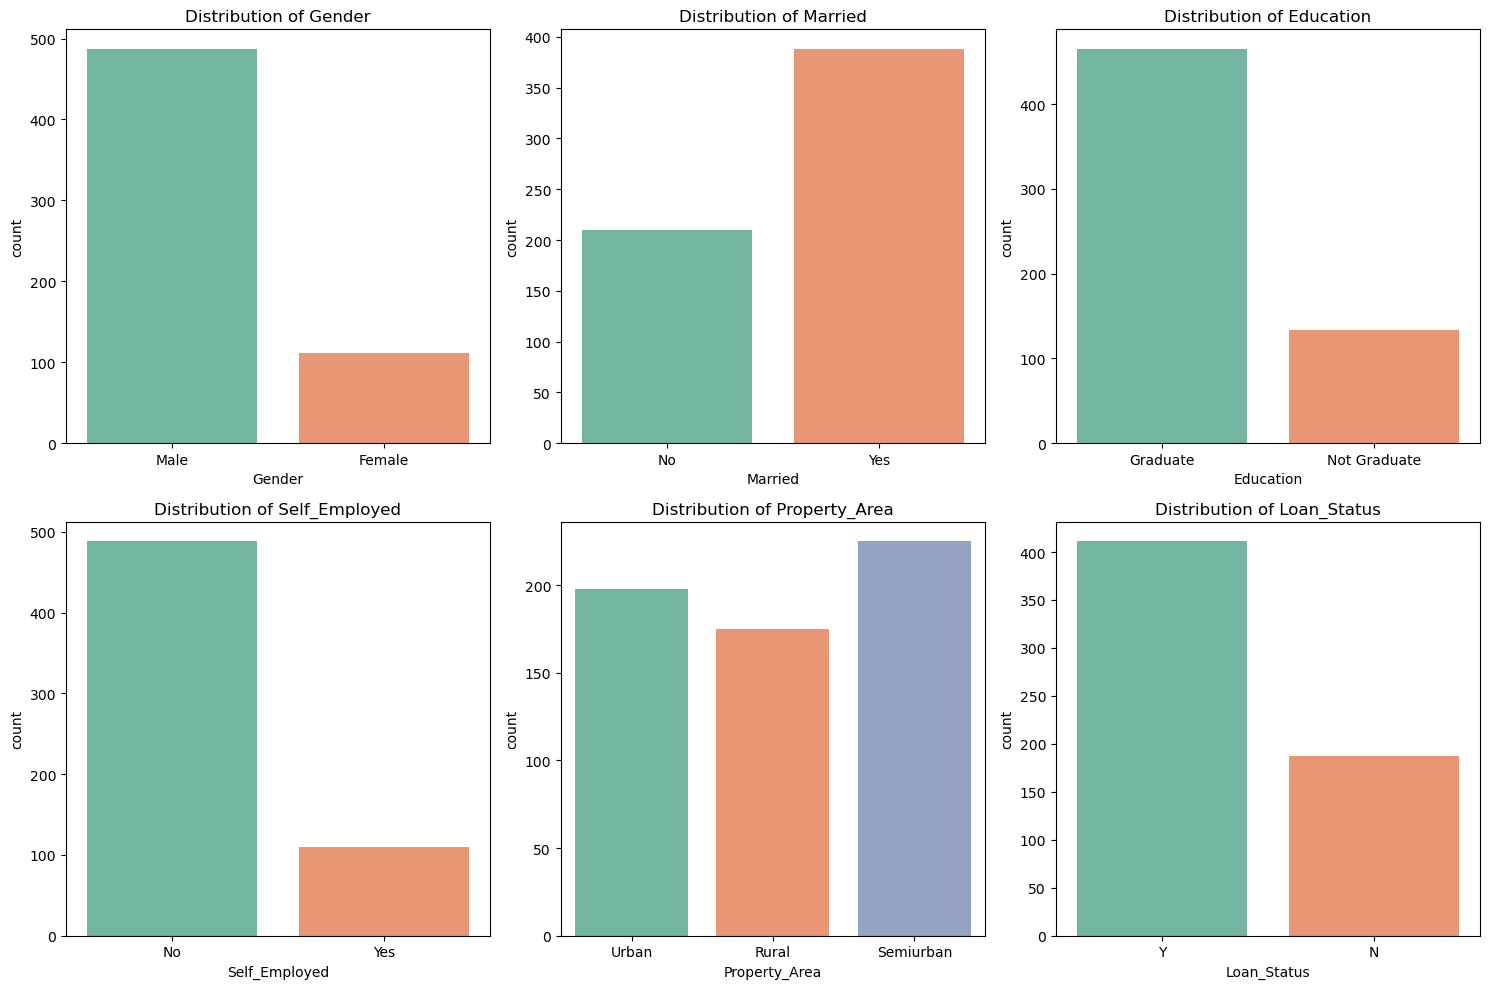

In [14]:
# List of categorical columns
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=col, data=df, hue=col, palette='Set2', legend=False)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### 2.2 Distribution Analysis (Histograms)
We examine the data distribution of continuous features to identify skewness and understand the range of values for applicants.

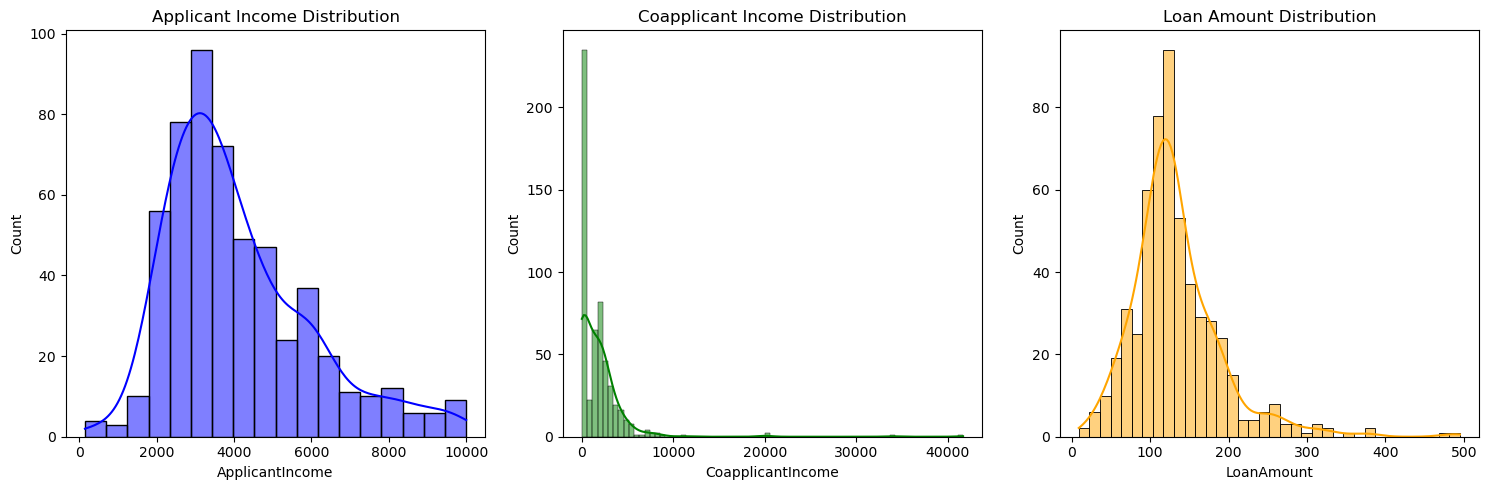

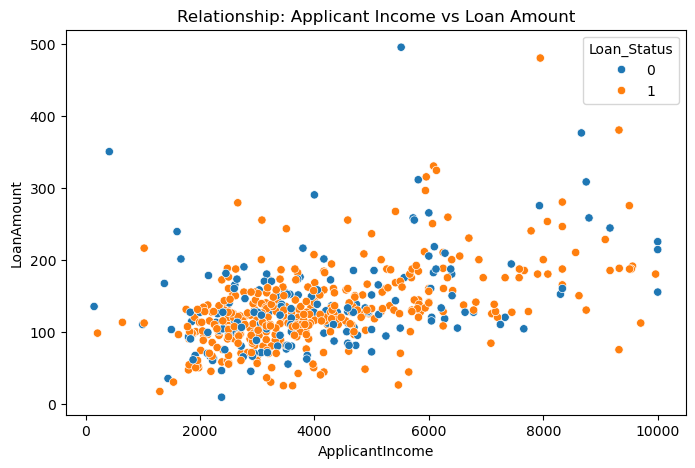

In [21]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['ApplicantIncome'], kde=True, color='blue')
plt.title('Applicant Income Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['CoapplicantIncome'], kde=True, color='green')
plt.title('Coapplicant Income Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['LoanAmount'], kde=True, color='orange')
plt.title('Loan Amount Distribution')
plt.tight_layout()
plt.show()

# 2.4 Relationship Analysis (Scatter Plots)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', data=df, hue='Loan_Status')
plt.title('Relationship: Applicant Income vs Loan Amount')
plt.show()

### 2.3 Outlier Detection
Using Box plots to identify extreme values (outliers) in numerical columns.

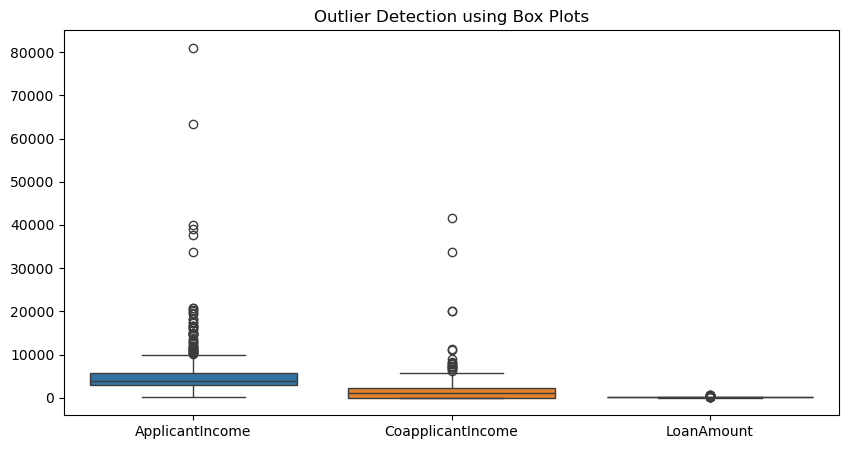

In [15]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']])
plt.title('Outlier Detection using Box Plots')
plt.show()

# 3. Data Cleaning
We will now handle duplicates, missing values, and treat the outliers detected in the previous step.

In [16]:
# 1. Handle Duplicates
df.drop_duplicates(inplace=True)

# 2. Manage Missing Values
# Numerical: Fill with Median
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# Categorical: Fill with Mode (Most frequent value)
cols_to_fill = ['Gender', 'Married', 'Dependents', 'Self_Employed']
for col in cols_to_fill:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3. Treat Outliers (using IQR method)
Q1 = df['ApplicantIncome'].quantile(0.25)
Q3 = df['ApplicantIncome'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['ApplicantIncome'] < (Q1 - 1.5 * IQR)) | (df['ApplicantIncome'] > (Q3 + 1.5 * IQR)))]

print("Data Cleaning Complete. Remaining Nulls:", df.isnull().sum().sum())

Data Cleaning Complete. Remaining Nulls: 0


# 4. Data Preparation
Converting categorical text data into numeric format using Encoding to make it ready for analysis.

In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Encode all object columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0.0,0,0,5849,0.0,127.0,360.0,1.0,2,1
1,1,1,1,1.0,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0.0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0.0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0.0,0,0,6000,0.0,141.0,360.0,1.0,2,1


# 5. Feature Analysis
Calculating Pearson correlation to identify which features strongly influence the Loan Status.

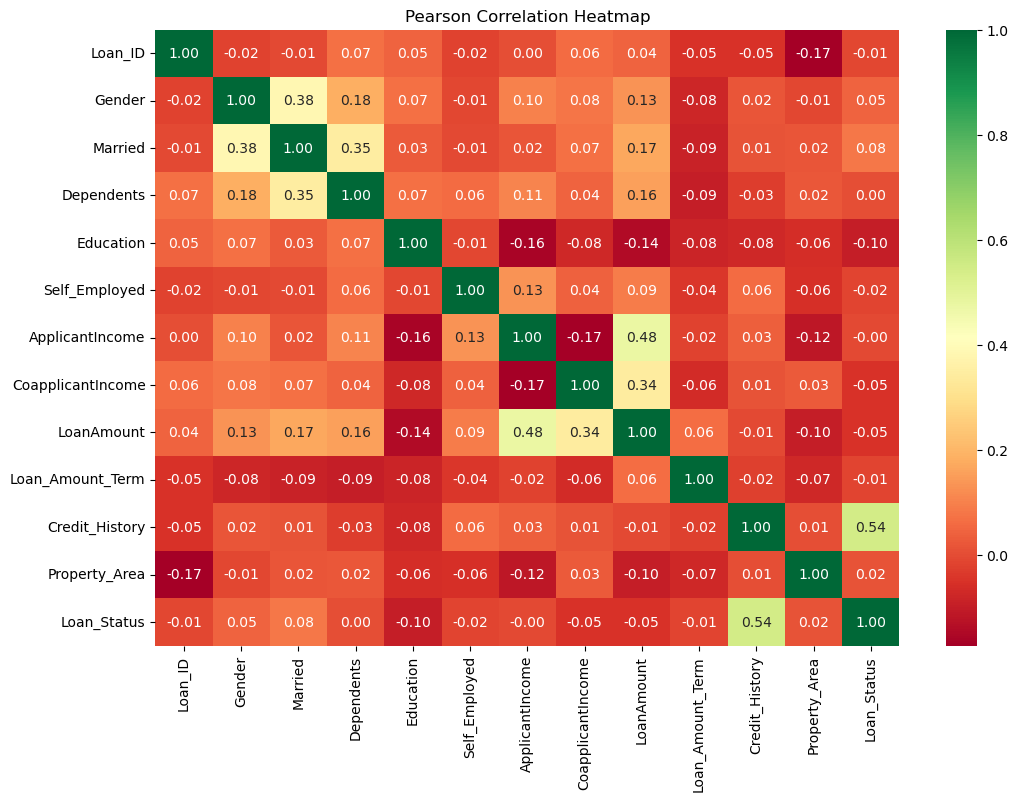

In [18]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Pearson Correlation Heatmap')
plt.show()

--- Feature Importance (R-Square) ---
Loan_Status          1.000000
Credit_History       0.297025
Education            0.009422
Married              0.006830
LoanAmount           0.002660
CoapplicantIncome    0.002561
Gender               0.002050
Self_Employed        0.000272
Property_Area        0.000226
Loan_Amount_Term     0.000210
Loan_ID              0.000069
ApplicantIncome      0.000008
Dependents           0.000005
Name: Loan_Status, dtype: float64


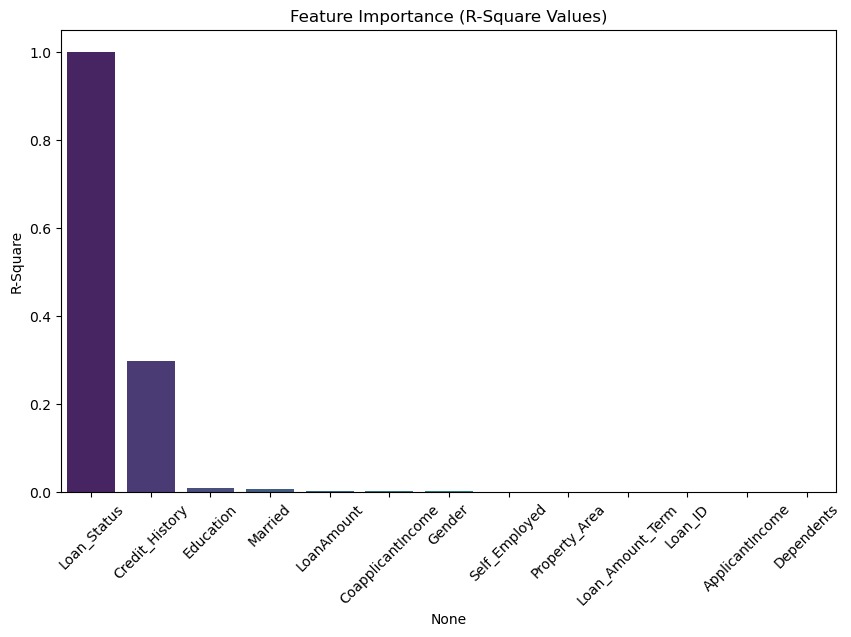

In [22]:
# Calculate R-squared
r_squared = (df.corr()['Loan_Status'] ** 2).sort_values(ascending=False)

print("--- Feature Importance (R-Square) ---")
print(r_squared)

# OPTIONAL: Visualize Feature Importance (Fixed Code)
plt.figure(figsize=(10, 6))
sns.barplot(x=r_squared.index, y=r_squared.values, hue=r_squared.index, palette='viridis', legend=False)
plt.xticks(rotation=45)
plt.title('Feature Importance (R-Square Values)')
plt.ylabel('R-Square')
plt.show()

# 6. Insights & Feature Selection

### 6.1 Significant Findings
1.  **Credit History is Critical:** The analysis shows a very strong correlation between `Credit_History` and `Loan_Status`. An applicant with a credit history of 1.0 is significantly more likely to be approved.
2.  **Income is Less Relevant:** Surprisingly, `ApplicantIncome` has a very weak linear correlation with loan approval. This suggests that simply having a high income is not enough if the credit history is bad.
3.  **Outliers:** We found and removed significant outliers in the Income column to prevent skewing the data.

### 6.2 Selected Features
Based on the R-square and Correlation analysis, the most impactful features selected for the prediction model are:
1.  **Credit_History** (Highest impact)
2.  **Education**
3.  **Married**
4.  **CoapplicantIncome**
5.  **LoanAmount**

These features show the strongest relationship with the target variable and should be prioritized for model training.